# Trick sequences (gaussian sampling)


In [1]:
from pathlib import Path

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from aitraf.data_ops.pose_and_bbox_extraction import _iter_frames
from aitraf.processing.utils import sample_frame_indices
from aitraf.utils import get_video_rotation_deg


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing data/ and src/.")


PROJECT_ROOT = find_repo_root(Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / "data"
CLIPS_DIR = DATA_DIR / "clips"
LABELS_PATH = DATA_DIR / "labels.jsonl"
EXPORT_DIR = PROJECT_ROOT / "notebooks" / "data" / "trick-taxonomies"

SAMPLE_FRAMES = 5
SAMPLING_DIST = "gaussian_stochastic"
TARGET_EXECUTION_SCORE = 3
GRID_EXPORT_PATH = EXPORT_DIR / "trick_taxonomy_grid.png"
REQUIRED_LABEL_COLUMNS = [
    "video",
    "trick",
    "execution_score",
    "ambiguous_score",
    "ambiguous_trick",
]

EXPORT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
def has_value(series: pd.Series) -> pd.Series:
    return series.notna() & series.astype("string").str.strip().ne("")


def load_labels(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing labels file: {path}")

    df = pd.read_json(path, lines=True)
    missing_columns = [column for column in REQUIRED_LABEL_COLUMNS if column not in df.columns]
    if missing_columns:
        raise RuntimeError(f"Missing required label columns: {missing_columns}")

    df["video_id"] = df["video"].map(lambda value: Path(str(value)).name if pd.notna(value) else pd.NA)
    df["clip_path"] = df["video_id"].map(lambda value: CLIPS_DIR / value if pd.notna(value) else pd.NA)
    df["clip_exists"] = df["clip_path"].map(lambda value: Path(value).exists() if pd.notna(value) else False)
    df["execution_score_numeric"] = pd.to_numeric(df["execution_score"], errors="coerce")
    df["has_ambiguous_score"] = has_value(df["ambiguous_score"])
    df["has_ambiguous_trick"] = has_value(df["ambiguous_trick"])

    missing_required = df.loc[~has_value(df["video"]) | ~has_value(df["trick"])]
    if not missing_required.empty:
        raise RuntimeError(f"Found {len(missing_required)} rows missing video or trick.")

    missing_clips = df.loc[~df["clip_exists"]]
    if not missing_clips.empty:
        sample = missing_clips["video_id"].head(5).tolist()
        raise RuntimeError(f"Found {len(missing_clips)} labels without local clips. Sample: {sample}")

    return df


labels_df = load_labels(LABELS_PATH)
usable_labels_df = labels_df.copy()

summary_df = pd.DataFrame(
    [
        {"metric": "label rows", "count": len(labels_df)},
        {"metric": "usable local clips", "count": len(usable_labels_df)},
        {"metric": "tricks", "count": usable_labels_df["trick"].nunique()},
        {"metric": "ambiguous trick rows", "count": int(labels_df["has_ambiguous_trick"].sum())},
        {"metric": "ambiguous score rows", "count": int(labels_df["has_ambiguous_score"].sum())},
    ]
)

display(summary_df)
display(usable_labels_df.head())


,metric,count
0,label rows,847
1,usable local clips,847
2,tricks,7
3,ambiguous trick rows,2
4,ambiguous score rows,118


,video,annotation_id,annotator,id,created_at,updated_at,lead_time,trick,key_foot,person,execution_score,ambiguous_score,ambiguous_trick,video_id,clip_path,clip_exists,execution_score_numeric,has_ambiguous_score,has_ambiguous_trick
0,s3://aitraf/clips/25-10-31 19-46-26 5688-00.00...,2539,1,11356,2026-04-24 10:14:30.183499+00:00,2026-04-24 14:51:47.161333+00:00,175.263,soul,right,Henrikas,2.0,None,None,25-10-31 19-46-26 5688-00.00.09.834-00.00.13.8...,/workspace/data/clips/25-10-31 19-46-26 5688-0...,True,2.0,False,False
1,s3://aitraf/clips/25-10-31 19-46-26 5688-00.00...,2540,1,11357,2026-04-24 10:14:30.183555+00:00,2026-04-27 14:32:51.337725+00:00,101.921,soul,right,Max,2.0,ambiguous_score,None,25-10-31 19-46-26 5688-00.00.25.739-00.00.29.2...,/workspace/data/clips/25-10-31 19-46-26 5688-0...,True,2.0,True,False
2,s3://aitraf/clips/25-10-31 19-46-26 5688-00.00...,2541,1,11358,2026-04-24 10:14:30.183593+00:00,2026-04-24 14:52:06.121537+00:00,42.061,soul,left,Henrikas,2.0,None,None,25-10-31 19-46-26 5688-00.00.35.696-00.00.40.5...,/workspace/data/clips/25-10-31 19-46-26 5688-0...,True,2.0,False,False
3,s3://aitraf/clips/25-10-31 19-46-26 5688-00.00...,2542,1,11359,2026-04-24 10:14:30.183632+00:00,2026-04-24 14:52:15.995784+00:00,35.957,soul,left,Max,2.0,None,None,25-10-31 19-46-26 5688-00.00.46.631-00.00.52.7...,/workspace/data/clips/25-10-31 19-46-26 5688-0...,True,2.0,False,False
4,s3://aitraf/clips/25-10-31 19-46-26 5688-00.00...,2543,1,11360,2026-04-24 10:14:30.183671+00:00,2026-04-24 14:52:23.904837+00:00,33.589,soul,right,Henrikas,2.0,None,None,25-10-31 19-46-26 5688-00.00.55.431-00.00.59.2...,/workspace/data/clips/25-10-31 19-46-26 5688-0...,True,2.0,False,False


In [3]:
def center_crop_square(frame):
    height, width = frame.shape[:2]
    size = min(height, width)
    top = (height - size) // 2
    left = (width - size) // 2
    return frame[top : top + size, left : left + size]


def load_gaussian_frames(row):
    clip_path = Path(row["clip_path"])
    rotation_deg = get_video_rotation_deg(clip_path)
    frames = list(_iter_frames(clip_path, rotation_deg))
    if not frames:
        raise RuntimeError(f"No frames found for clip: {clip_path}")

    indices = sample_frame_indices(
        len(frames),
        SAMPLE_FRAMES,
        SAMPLING_DIST,
        source=clip_path,
    )
    return [center_crop_square(frames[idx]) for idx in indices]


def pick_trick_row(trick_df: pd.DataFrame, trick: str) -> pd.Series:
    if trick_df.empty:
        raise RuntimeError(f"No rows for trick '{trick}'.")

    candidates = trick_df.loc[~trick_df["has_ambiguous_trick"]].copy()
    if candidates.empty:
        raise RuntimeError(f"No unambiguous trick rows found for trick '{trick}'.")

    target_scored = candidates.loc[
        candidates["execution_score_numeric"] == TARGET_EXECUTION_SCORE
    ].copy()
    if target_scored.empty:
        raise RuntimeError(
            f"No {TARGET_EXECUTION_SCORE}-star rows found for trick '{trick}'."
        )

    target_scored = target_scored.sort_values(
        ["has_ambiguous_score", "video_id"],
        ascending=[True, True],
    )
    return target_scored.iloc[0]


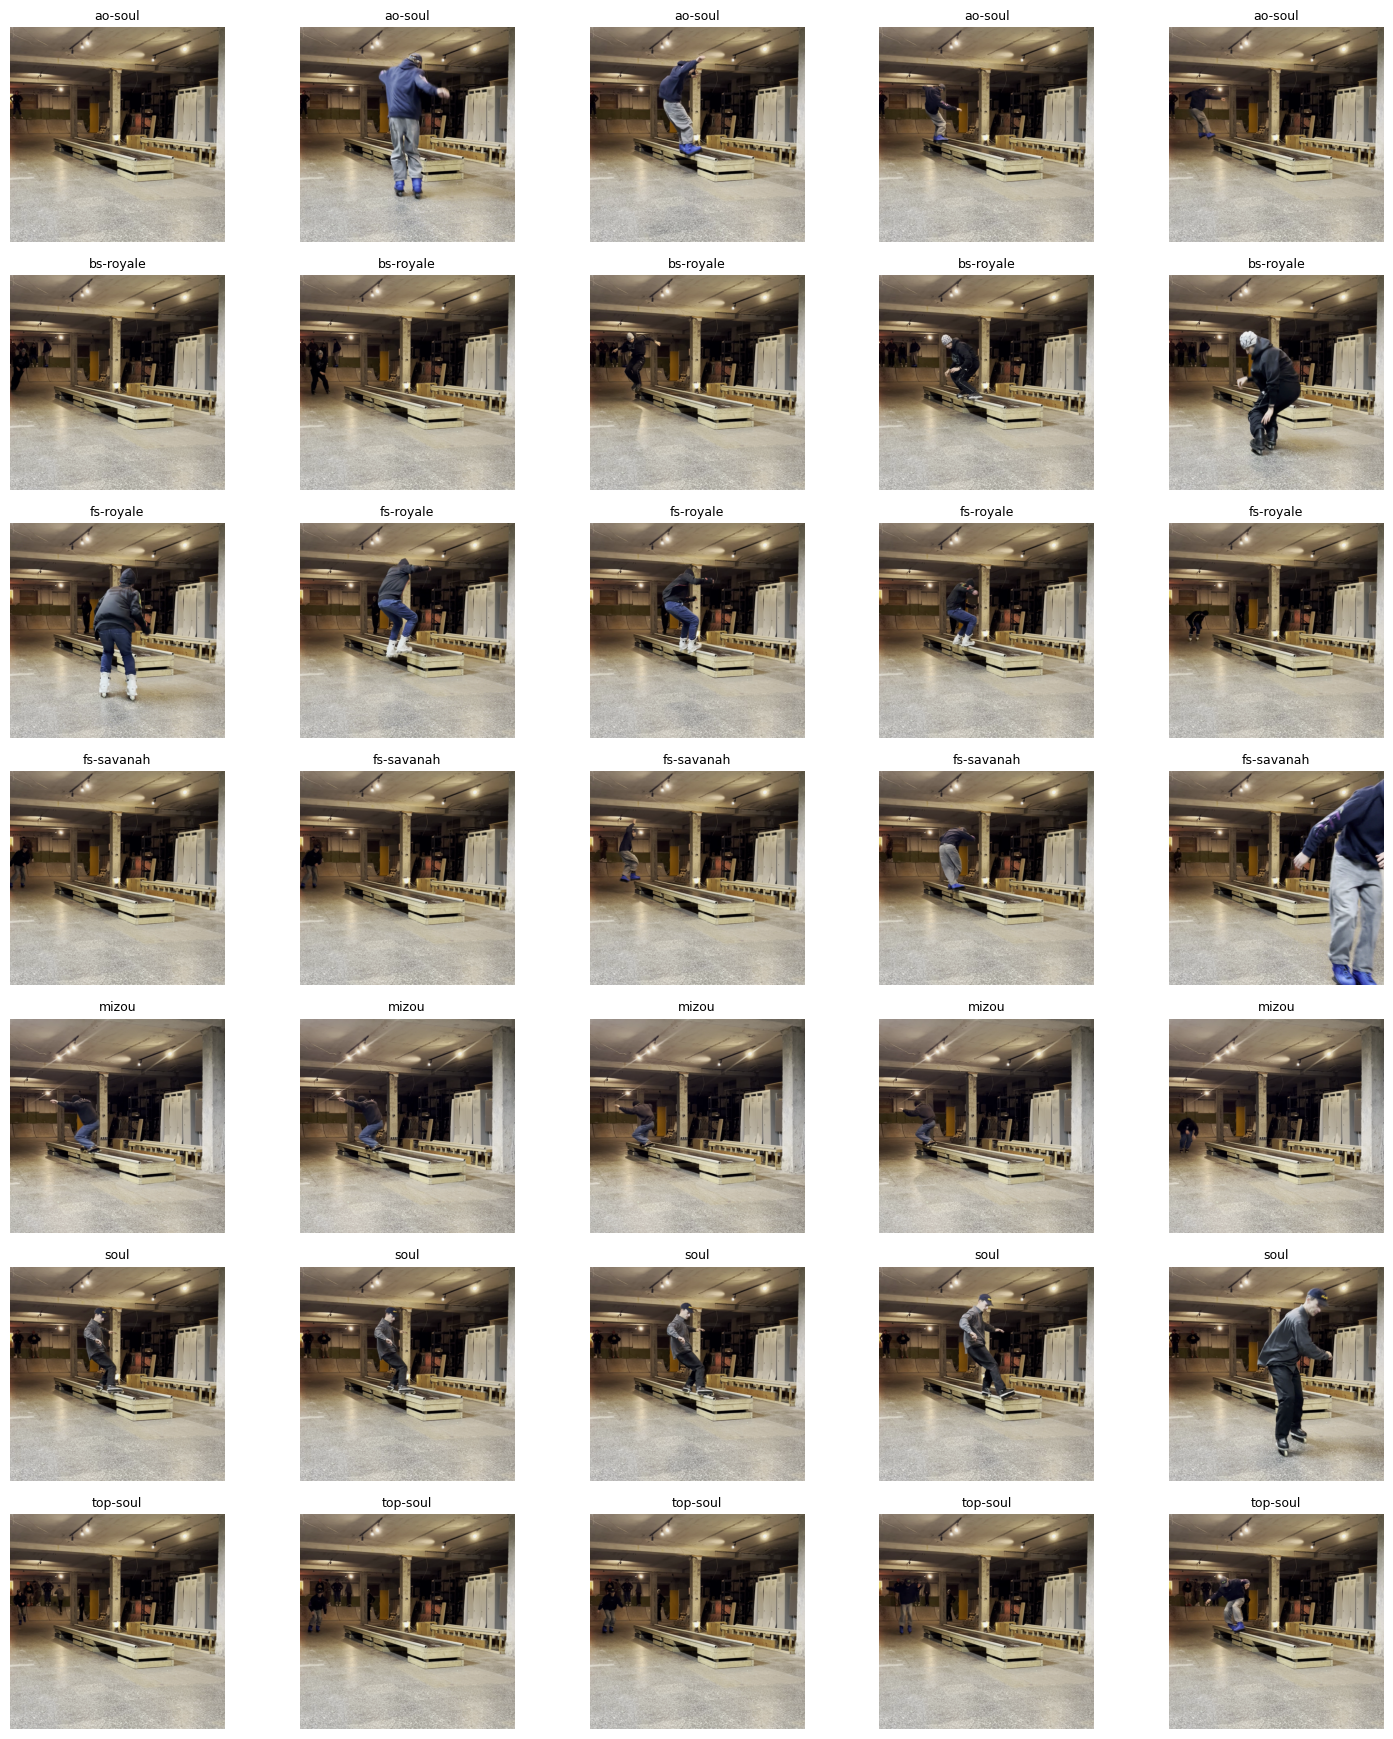

,trick,video_id,execution_score,has_ambiguous_score,has_ambiguous_trick,target_execution_score,export_dir
0,ao-soul,25-11-02 19-14-55 5695-00.01.25.894-00.01.29.2...,3.0,False,False,3,notebooks/data/trick-taxonomies/ao-soul
1,bs-royale,25-11-02 19-14-55 5695-00.08.06.713-00.08.11.9...,3.0,False,False,3,notebooks/data/trick-taxonomies/bs-royale
2,fs-royale,25-11-02 19-14-55 5695-00.01.14.458-00.01.18.6...,3.0,False,False,3,notebooks/data/trick-taxonomies/fs-royale
3,fs-savanah,25-11-02 19-14-55 5695-00.05.28.741-00.05.32.6...,3.0,False,False,3,notebooks/data/trick-taxonomies/fs-savanah
4,mizou,25-10-31 19-54-19 5689-00.03.16.913-00.03.22.7...,3.0,False,False,3,notebooks/data/trick-taxonomies/mizou
5,soul,25-11-02 19-14-55 5695-00.00.04.305-00.00.07.8...,3.0,False,False,3,notebooks/data/trick-taxonomies/soul
6,top-soul,25-11-02 19-14-55 5695-00.02.33.574-00.02.37.2...,3.0,False,False,3,notebooks/data/trick-taxonomies/top-soul


/workspace/notebooks/data/trick-taxonomies/trick_taxonomy_grid.png


In [4]:
tricks = sorted(usable_labels_df["trick"].dropna().unique().tolist())
selected_rows = []

fig, axes = plt.subplots(
    len(tricks),
    SAMPLE_FRAMES,
    figsize=(SAMPLE_FRAMES * 3, len(tricks) * 2.5),
    squeeze=False,
)

for row_idx, trick in enumerate(tricks):
    trick_df = usable_labels_df.loc[usable_labels_df["trick"] == trick]
    row = pick_trick_row(trick_df, trick)
    frames = load_gaussian_frames(row)

    export_dir = EXPORT_DIR / trick
    export_dir.mkdir(parents=True, exist_ok=True)

    selected_rows.append(
        {
            "trick": trick,
            "video_id": row["video_id"],
            "execution_score": row["execution_score_numeric"],
            "has_ambiguous_score": row["has_ambiguous_score"],
            "has_ambiguous_trick": row["has_ambiguous_trick"],
            "target_execution_score": TARGET_EXECUTION_SCORE,
            "export_dir": str(export_dir.relative_to(PROJECT_ROOT)),
        }
    )

    for col_idx, frame in enumerate(frames):
        image_path = export_dir / f"{col_idx + 1}.png"
        imageio.imwrite(image_path, frame)

        ax = axes[row_idx][col_idx]
        ax.imshow(frame)
        ax.set_title(trick, fontsize=9)
        ax.axis("off")

plt.tight_layout()
fig.savefig(GRID_EXPORT_PATH, dpi=150, bbox_inches="tight")
plt.show()

selected_df = pd.DataFrame(selected_rows)
display(selected_df)
print(GRID_EXPORT_PATH)
